# Laptop Price Analyzer and Recommendation System

This project analyzes laptop specifications and
prices and recommends laptops based on user
requirements.

### Technologies

- Python
- Numpy 
- Pandas 
- Matplotliblib
- Seaborn 
- Scikit-learn 
- Jupyter Notebook

In [1]:
import numpy as np 
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt 

## 1. Creating the Dataset

We will generate a synthetic laptop dataset 
containing specifications such as brand, processor, RAM, storage, GPU, battery life, weight and price.

In [2]:
np.random.seed(42)

number_of_laptops = 300

In [3]:
brands = [
    "Lenovo",
    "HP",
    "Dell",
    "ASUS",
    "Acer",
    "Apple",
    "MSI"
]

processors = [
    "Core i3",
    "Core i5",
    "Core i7",
    "Ryzen 5",
    "Ryzen 7",
    "M1",
    "M2"
]

gpus = [
    "Integrated",
    "GTX 1650",
    "RTX 2050",
    "RTX 3050",
    "RTX 4060"
]

use_cases = [

    "Office",
    "Programming",
    "Design",
    "Gaming",
    "Video Editing"
]

In [4]:
df = pd.DataFrame({
    "brands": np.random.choice(
        brands,
        number_of_laptops
    ),

    "processor": np.random.choice(
        processors,
        number_of_laptops
    ),

    "ram_gb": np.random.choice(
        [4,8,12,32,64],
        number_of_laptops
    ),
    "Storage_gb": np.random.choice(
        [256,512,1024,2028],
        number_of_laptops
    ),

    "gpu": np.random.choice(
        gpus,
        number_of_laptops
    ),

    "screen_size": np.round(
        np.random.uniform(13.3, 17.3,
            number_of_laptops),
            1
    ),

    "battery_hours": np.round(
        np.random.uniform(4,14,
                number_of_laptops),
                1
    ),

    "weight_kg": np.round(
        np.random.uniform(1.2, 3.0,
                          number_of_laptops),
                          1
    ),

    "use_cases": np.random.choice(
        use_cases,
        number_of_laptops
    )        
})

In [5]:
df.head(5)

,brands,processor,ram_gb,Storage_gb,gpu,screen_size,battery_hours,weight_kg,use_cases
0,MSI,Core i7,8,2028,RTX 2050,16.4,8.3,1.7,Design
1,ASUS,Core i5,12,256,Integrated,13.6,13.8,1.7,Design
2,Acer,Core i7,8,512,GTX 1650,16.6,5.5,2.5,Office
3,MSI,M2,4,256,RTX 3050,15.0,8.6,2.7,Gaming
4,Dell,Core i7,64,2028,RTX 2050,17.0,10.8,2.4,Video Editing


In [6]:
processor_score = {
    "Core i3": 1,
    "Core i5":2,
    "Core i7":3,
    "Ryzen 5":2,
    "Ryzen 7":3,
    "M1":3,
    "M2":4
}


gpu_scores = {
    "Integrated":0,
    "GTX 1650":1,
    "RTX 2050":2,
    "RTX 3050":3,
    "RTX 4060":5
}

In [9]:
df["processor_score"] = df["processor"].map(
    processor_score
)


df["gpu_scores"] = df["gpu"].map(
    gpu_scores
)

In [7]:
df.head(5)

,brands,processor,ram_gb,Storage_gb,gpu,screen_size,battery_hours,weight_kg,use_cases
0,MSI,Core i7,8,2028,RTX 2050,16.4,8.3,1.7,Design
1,ASUS,Core i5,12,256,Integrated,13.6,13.8,1.7,Design
2,Acer,Core i7,8,512,GTX 1650,16.6,5.5,2.5,Office
3,MSI,M2,4,256,RTX 3050,15.0,8.6,2.7,Gaming
4,Dell,Core i7,64,2028,RTX 2050,17.0,10.8,2.4,Video Editing


In [10]:
df["price"] = (
    50000
    + df["ram_gb"] * 2500
    + df["Storage_gb"] * 40
    + df["processor_score"] * 3000
    + df["gpu_scores"] * 40000
    + df["screen_size"] * 3000
    + np.random.normal(
        0,
        15000,
        number_of_laptops
    )
)

In [11]:
df["price"] = df["price"].clip(
    lower=45000
)

df["price"] = df["price"].round(-2)

In [12]:
df["model"] = (
    df["brands"]
    + " "
    + df["processor"]
    + " "
    + df["ram_gb"].astype(str)
    + "GB"
)

In [13]:
df[
    [
        "model",
        "ram_gb",
        "Storage_gb",
        "gpu",
        "price"
    ]
].head()

,model,ram_gb,Storage_gb,gpu,price
0,MSI Core i7 8GB,8,2028,RTX 2050,319600.0
1,ASUS Core i5 12GB,12,256,Integrated,109600.0
2,Acer Core i7 8GB,8,512,GTX 1650,195000.0
3,MSI M2 4GB,4,256,RTX 3050,230500.0
4,Dell Core i7 64GB,64,2028,RTX 2050,443000.0


In [14]:
df.to_csv(
 "../data/laptop.csv",
 index=False   
)

In [15]:
df.isnull().sum()

df.duplicated().sum()

np.int64(0)

In [16]:
df["price"].mean()

np.float64(291263.3333333333)

In [17]:
df["price"].median()

np.float64(281850.0)

In [18]:
df["price"].min()

np.float64(90800.0)

In [19]:
df["price"].max()

np.float64(550100.0)

In [20]:
df.loc[
    df["price"].idxmin()
]

brands                         HP
processor                 Core i3
ram_gb                          4
Storage_gb                    256
gpu                    Integrated
screen_size                  13.9
battery_hours                 8.8
weight_kg                     1.8
use_cases             Programming
processor_score                 1
gpu_scores                      0
price                     90800.0
model              HP Core i3 4GB
Name: 246, dtype: object

In [21]:
df.loc[
    df["price"].idxmax()
]

brands                          MSI
processor                   Core i3
ram_gb                           64
Storage_gb                     2028
gpu                        RTX 4060
screen_size                    13.5
battery_hours                   6.5
weight_kg                       1.5
use_cases                    Gaming
processor_score                   1
gpu_scores                        5
price                      550100.0
model              MSI Core i3 64GB
Name: 169, dtype: object

## Price Distribution

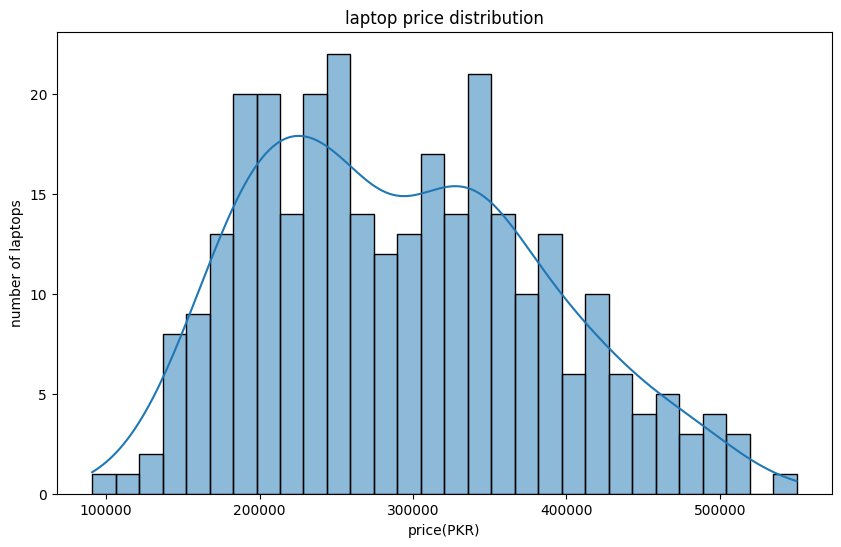

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="price",
    bins=30,
    kde=True
)

plt.title("laptop price distribution")
plt.xlabel("price(PKR)")
plt.ylabel("number of laptops")

plt.show()